In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

In [7]:
df = pd.read_csv("PS_20174392719_1491204439457_log.csv")

In [8]:
print("=" * 70)
print("SHAPE & DTYPES")
print("=" * 70)
print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(df.dtypes.to_string(), "\n")
 
print("First 5 rows:")
print(df.head(), "\n")

SHAPE & DTYPES
Rows:    6,362,620
Columns: 11
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64 

First 5 rows:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig     nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36  M1979787155             0.0             0.0        0               0
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72  M2044282225             0.0             0.0        0               0
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   C553264065             0.0             0.0        1               0
3     1  CASH_OUT    181.00   C840083671          181.0            0.00    C38997010

In [9]:
print("=" * 70)
print("MISSING VALUES & DUPLICATES")
print("=" * 70)
missing = df.isna().sum()
print("Missing per column:")
print(missing[missing > 0].to_string() if missing.sum() else "  None", "\n")
print(f"Duplicate rows: {df.duplicated().sum():,}\n")

MISSING VALUES & DUPLICATES
Missing per column:
  None 

Duplicate rows: 0



In [10]:
print("=" * 70)
print("CLASS BALANCE (isFraud)")
print("=" * 70)
counts = df["isFraud"].value_counts().sort_index()
pct = df["isFraud"].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({"count": counts, "percent": pct.round(4)}).to_string(), "\n")
 
# PaySim also has an `isFlaggedFraud` column — the built-in rule-based flag.
# Useful to show the baseline you are trying to beat.
print("isFlaggedFraud vs isFraud cross-tab:")
print(pd.crosstab(df["isFraud"], df["isFlaggedFraud"],
                  rownames=["isFraud"], colnames=["isFlaggedFraud"]), "\n")

CLASS BALANCE (isFraud)
           count  percent
isFraud                  
0        6354407  99.8709
1           8213   0.1291 

isFlaggedFraud vs isFraud cross-tab:
isFlaggedFraud        0   1
isFraud                    
0               6354407   0
1                  8197  16 



In [11]:
print("=" * 70)
print("TRANSACTION TYPES")
print("=" * 70)
type_counts = df["type"].value_counts()
print("Overall type distribution:")
print(type_counts.to_string(), "\n")

fraud_by_type = (
    df.groupby("type")["isFraud"]
      .agg(["sum", "count", "mean"])
      .rename(columns={"sum": "fraud_count", "count": "total", "mean": "fraud_rate"})
      .sort_values("fraud_rate", ascending=False)
)
fraud_by_type["fraud_rate"] = (fraud_by_type["fraud_rate"] * 100).round(4)
print("Fraud rate by transaction type (%):")
print(fraud_by_type.to_string(), "\n")

TRANSACTION TYPES
Overall type distribution:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432 

Fraud rate by transaction type (%):
          fraud_count    total  fraud_rate
type                                      
TRANSFER         4097   532909      0.7688
CASH_OUT         4116  2237500      0.1840
CASH_IN             0  1399284      0.0000
DEBIT               0    41432      0.0000
PAYMENT             0  2151495      0.0000 



In [12]:
print("=" * 70)
print("NUMERIC SUMMARY")
print("=" * 70)
numeric_cols = ["amount", "oldbalanceOrg", "newbalanceOrig",
                "oldbalanceDest", "newbalanceDest", "step"]
print("All rows:")
print(df[numeric_cols].describe().round(2), "\n")
print("Fraud only:")
print(df.loc[df["isFraud"] == 1, numeric_cols].describe().round(2), "\n")

NUMERIC SUMMARY
All rows:
            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest        step
count   6362620.00     6362620.00      6362620.00    6.362620e+06    6.362620e+06  6362620.00
mean     179861.90      833883.10       855113.67    1.100702e+06    1.224996e+06      243.40
std      603858.23     2888242.67      2924048.50    3.399180e+06    3.674129e+06      142.33
min           0.00           0.00            0.00    0.000000e+00    0.000000e+00        1.00
25%       13389.57           0.00            0.00    0.000000e+00    0.000000e+00      156.00
50%       74871.94       14208.00            0.00    1.327057e+05    2.146614e+05      239.00
75%      208721.48      107315.18       144258.41    9.430367e+05    1.111909e+06      335.00
max    92445516.64    59585040.37     49585040.37    3.560159e+08    3.561793e+08      743.00 

Fraud only:
            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  newbalanceDest     step
count      8213.00     

Plots saved to: /Users/zoecaballero/Documents/GitHub/fraud-detection-agent/data/eda_plots

Done.


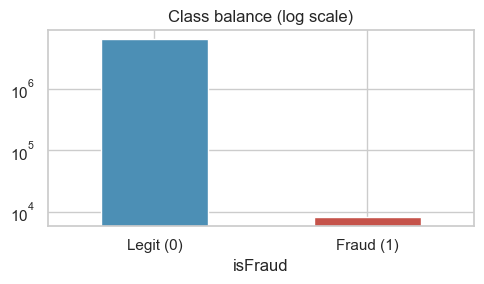

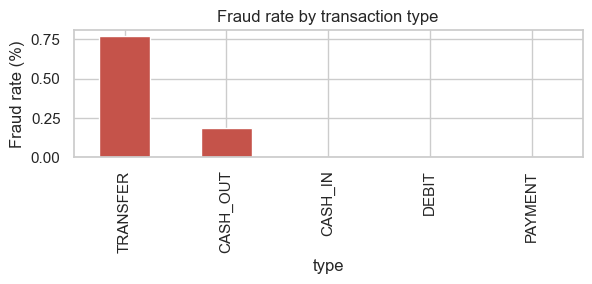

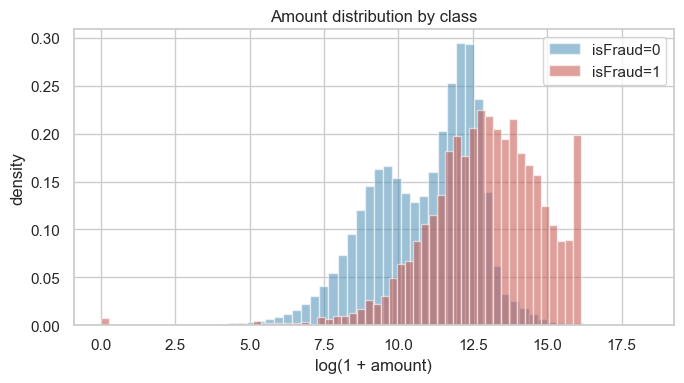

In [14]:
out_dir = Path("eda_plots")
out_dir.mkdir(exist_ok=True)
sns.set_theme(style="whitegrid")
 
# Class balance bar
fig, ax = plt.subplots(figsize=(5, 3))
counts.plot(kind="bar", ax=ax, color=["#4c8fb5", "#c5534a"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_title("Class balance (log scale)")
ax.set_yscale("log")
fig.tight_layout(); fig.savefig(out_dir / "01_class_balance.png", dpi=120)
 
# Fraud rate by type
fig, ax = plt.subplots(figsize=(6, 3))
fraud_by_type["fraud_rate"].plot(kind="bar", ax=ax, color="#c5534a")
ax.set_ylabel("Fraud rate (%)"); ax.set_title("Fraud rate by transaction type")
fig.tight_layout(); fig.savefig(out_dir / "02_fraud_rate_by_type.png", dpi=120)
 
# Amount distribution by class (log x)
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [(0, "#4c8fb5"), (1, "#c5534a")]:
    sub = df.loc[df["isFraud"] == label, "amount"]
    ax.hist(np.log1p(sub), bins=60, alpha=0.55,
            label=f"isFraud={label}", color=color, density=True)
ax.set_xlabel("log(1 + amount)"); ax.set_ylabel("density")
ax.legend(); ax.set_title("Amount distribution by class")
fig.tight_layout(); fig.savefig(out_dir / "03_amount_by_class.png", dpi=120)
 
 
print(f"Plots saved to: {out_dir.resolve()}\n")
print("Done.")